# 本次模擬cmd log資訊

* 只保留run.log最後200行的資訊和AMReX finalize(如下)


In [1]:
start_time = None
end_time = None
elapsed = None

with open("run.log") as f:
    for line in f:
        line = line.strip()

        if line.startswith("START:"):
            start_time = line.replace("START:", "").strip()

        elif line.startswith("END:"):
            end_time = line.replace("END:", "").strip()

        elif line.startswith("Total run time"):
            elapsed = line.replace("Total run time", "").strip()

print("Simulation Information")
print("----------------------")
print(f"Start Time : {start_time}")
print(f"End Time   : {end_time}")
print(f"Run Time   : {elapsed}")

Simulation Information
----------------------
Start Time : None
End Time   : None
Run Time   : 11500.19151 seconds


# 使用者設定

In [2]:
import re
from pathlib import Path

import yt
import numpy as np
import pandas as pd


# =========================
# User settings
# =========================#"/home/gkaiwi58/FAM/FerroX/Exec/MFIM_mod_1/"
PLOT_DIR = Path("./plts")          # plotfile 所在資料夾
PLOT_PREFIX = "plt"
PLOT_INTERVAL = 10000000           # 你的 plot_int，例如 100

# 如果你的 field 名稱不是 ("boxlib", "Phi")，後面會自動列出 field_list 方便你改
PHI_FIELD_CANDIDATES = [
    ("boxlib", "Phi"),
    ("boxlib", "phi"),
    ("boxlib", "PoissonPhi"),
    "Phi",
    "phi",
    "PoissonPhi",
]

wanted = {"alpha", "beta", "gamma", "BigGamma", "g11", "g44", "FE_lo", "FE_hi"}

def parse_value(values):
    vals = [float(v) for v in values.split()]
    return vals[0] if len(vals) == 1 else vals

params = {}

with open("inputs") as f:
    for line in f:
        line = line.strip()
        if not line or "=" not in line:
            continue

        key, values = line.split("=", 1)
        if key.strip() in wanted:
            params[key.strip()] = parse_value(values.strip())

# FE layer range, unit: nm
FE_Z_LO_NM = params["FE_lo"][2] / 1e-9
FE_Z_HI_NM = params["FE_hi"][2] / 1e-9

# 如果你想只畫 FE 的 x 範圍，也可以打開這兩行
# 若是 MFIS 全幅 FE，通常用整個 x 範圍即可

FE_X_LO_NM = params["FE_lo"][0] / 1e-9
FE_X_HI_NM = params["FE_hi"][0] / 1e-9

FE_Y_LO_NM = params["FE_lo"][1] / 1e-9
FE_Y_HI_NM = params["FE_hi"][1] / 1e-9

ALPHA = params["alpha"]
BETA = params["beta"]
SMALL_GAMMA = params["gamma"]
BIG_GAMMA = params["BigGamma"]
G11 = params["g11"]
G44 = params["g44"]
T_FE = 1e-9 * (FE_Z_HI_NM - FE_Z_LO_NM)  # FE layer thickness, unit: m

print("Parameters:")
print(f"  ALPHA = {ALPHA:.3e}")
print(f"  BETA = {BETA:.3e}")
print(f"  SMALL_GAMMA = {SMALL_GAMMA:.3e}")
print(f"  BIG_GAMMA = {BIG_GAMMA:.3e}")
print(f"  G11 = {G11:.3e}")
print(f"  G44 = {G44:.3e}")
print(f"  FE layer thickness = {T_FE:.3e} m")
# 3D sweep plot要畫的電壓欄位：-4.5, -4.0, ..., 4.5
VOLTAGES = np.arange(-4.5, 5.0, 0.5)
# 3D contour 要畫的plotfile


Parameters:
  ALPHA = -6.250e+09
  BETA = 1.000e+11
  SMALL_GAMMA = 1.500e+11
  BIG_GAMMA = 1.000e+02
  G11 = 1.000e-09
  G44 = 1.000e-09
  FE layer thickness = 6.000e-09 m


## Utils

In [3]:
def to_numpy(field_data):
    try:
        return field_data.to_ndarray()
    except AttributeError:
        return field_data.v

def read_full_field_from_grids(ds, field):
    """
    Read a cell-centered AMReX field from all yt grids
    and stitch them into one full-domain numpy array.

    Return:
        full: numpy array with shape ds.domain_dimensions
    """
    dims = np.array(ds.domain_dimensions, dtype=int)
    full = np.empty(tuple(dims), dtype=float)

    domain_lo = ds.domain_left_edge.to_value()
    domain_hi = ds.domain_right_edge.to_value()
    dx = (domain_hi - domain_lo) / dims

    for grid in ds.index.grids:
        arr = to_numpy(grid[field])

        left = grid.LeftEdge.to_value()

        # grid start index in global domain
        start = np.rint((left - domain_lo) / dx).astype(int)

        nx, ny, nz = arr.shape
        i0, j0, k0 = start
        i1, j1, k1 = i0 + nx, j0 + ny, k0 + nz

        full[i0:i1, j0:j1, k0:k1] = arr

    return full

def get_step_from_name(name):
    m = re.fullmatch(r"plt(\d+)", str(name))
    return int(m.group(1)) if m else None


def find_plot_names(plot_dir):
    names = []
    for p in plot_dir.iterdir():
        if p.is_dir() and re.fullmatch(r"plt\d+", p.name):
            names.append(p.name)
    names.sort(key=lambda n: get_step_from_name(n))
    return names

In [4]:
from pathlib import Path
import yt


plot_paths = sorted([p for p in PLOT_DIR.glob(f"{PLOT_PREFIX}*") if p.is_dir()])

# 只要名稱 (plt000100, ...)
plot_names = [p.name for p in plot_paths]

print("Available plotfiles:")
for name in plot_names:
    print("  ", name)
    
print(len(plot_names), "plotfiles found in", PLOT_DIR)
PLOTFILE_NAME = plot_names[30] 


Available plotfiles:
   plt00000000
   plt00004926
   plt00005645
   plt00007499
   plt00008683
   plt00010475
   plt00015731
   plt00020615
   plt00022091
   plt00024241
   plt00027123
   plt00028138
   plt00029458
   plt00031314
   plt00031976
   plt00033556
   plt00034914
   plt00035553
   plt00036587
   plt00037038
   plt00037654
   plt00038530
   plt00040083
   plt00042400
   plt00044054
   plt00045782
   plt00048267
   plt00049875
   plt00052519
   plt00054764
   plt00055462
   plt00057281
   plt00058068
   plt00060540
   plt00062409
   plt00062944
   plt00064102
   plt00064567
   plt00065136
   plt00066034
   plt00067875
   plt00069343
   plt00070804
   plt00072429
   plt00074200
   plt00075783
   plt00078537
47 plotfiles found in plts


## 探索yt資料結構

### dir(ds) # 列出 ds 所有(variable和property和method)

* Note: variable和property和method統稱attribute

In [5]:
ds = yt.load(PLOT_DIR/plot_names[0])  # 載入指定的 plotfile
dir(ds) # 列出 ds 所有變數和屬性和方法
#[a for a in dir(ds) if not a.startswith("_")]

yt : [INFO     ] 2026-06-25 22:27:51,095 Parameters: current_time              = 0.0
yt : [INFO     ] 2026-06-25 22:27:51,095 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:27:51,096 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:27:51,096 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


['__abstractmethods__',
 '__annotate_func__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slots__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_add_object_class',
 '_arr',
 '_assign_unit_system',
 '_create_unit_registry',
 '_default_cparam_filename',
 '_determined_fields',
 '_field_info',
 '_field_info_class',
 '_field_list',
 '_find_extremum',
 '_force_periodicity',
 '_get_field_info',
 '_get_field_info_helper',
 '_guess_candidates',
 '_hash',
 '_header_mesh_start',
 '_index_class',
 '_input_filename',
 '_instantiated',
 '_instantiated_index',
 '_ionization_label_format',
 '_is_valid',
 '_is_withi

### 用key word查看dir(ds)中可能會用到的attribute

In [6]:
for a in dir(ds): # 列出 ds 裡有哪些屬性和方法，特別是包含 "domain"
    if "domain" in a.lower():
        print(a)

_is_within_domain
domain_center
domain_dimensions
domain_left_edge
domain_offset
domain_right_edge
domain_width


In [7]:
for a in dir(ds): # 列出 ds 裡有哪些屬性和方法，特別是包含 "field"
    if "field" in a.lower():
        print(a)

_determined_fields
_field_info
_field_info_class
_field_list
_get_field_info
_get_field_info_helper
add_deposited_particle_field
add_field
add_gradient_fields
add_mesh_sampling_particle_field
create_field_info
default_field
default_species_fields
derived_field_list
field_info
field_list
field_units
fields
fields_detected
find_field_values_at_point
find_field_values_at_points
particle_fields_by_type
set_field_label_format
setup_deprecated_fields


In [8]:
for a in dir(ds): # 列出 ds 裡有哪些屬性和方法，特別是包含 "index"
    if "index" in a.lower():
        print(a)

_index_class
_instantiated_index
index


* **grid相關attribute在index內**

In [9]:
for a in dir(ds.index): # 列出 ds.index 裡有哪些屬性和方法，特別是包含 "index"
    if "grid" in a.lower():
        print(a)

_count_grids
_get_grid_objs
_get_grid_tree
_get_grids
_grid_chunksize
_grids
_initialize_grid_arrays
_populate_grid_objects
grid
grid_corners
grid_dimensions
grid_left_edge
grid_levels
grid_particle_count
grid_right_edge
grid_start_index
grids
lock_grids_to_parents
num_grids
select_grids


In [10]:
for a in dir(ds.index.grids[0]): # 列出 ds.index.grids[0] 裡有哪些屬性和方法，特別是包含 "index"
    
        print(a)

ActiveDimensions
Children
LeftEdge
Level
NumberOfParticles
OverlappingSiblings
Parent
RightEdge
__abstractmethods__
__add__
__and__
__annotate_func__
__class__
__delattr__
__delitem__
__dict__
__dir__
__doc__
__eq__
__firstlineno__
__format__
__ge__
__getattribute__
__getitem__
__getstate__
__gt__
__hash__
__init__
__init_subclass__
__int__
__invert__
__le__
__lt__
__module__
__ne__
__new__
__or__
__reduce__
__reduce_ex__
__repr__
__setattr__
__setitem__
__sizeof__
__slots__
__static_attributes__
__str__
__sub__
__subclasshook__
__weakref__
__xor__
_abc_impl
_activate_cache
_base_offset
_cache_mask
_child_index_mask
_child_indices
_child_mask
_children_ids
_chunk_info
_chunked_read
_compute_extrema
_con_args
_container_fields
_count_particles
_current_chunk
_current_fluid_type
_current_particle_type
_data_source
_debug
_default_field_parameters
_derived_quantity_chunking
_determine_fields
_distributed
_ds_hold
_extrema_cache
_field_cache
_field_lock
_field_parameter_state
_field_type_s

## yt dataset

* 可以從上一個部份"探索yt資料結構"找想用的attribute

In [11]:
print("========== Dataset ==========")
print("type:", type(ds))
print("用SI單位")
print("current_time(s):", ds.current_time)
print("domain_left_edge(m) :", ds.domain_left_edge)
print("domain_right_edge(m):", ds.domain_right_edge)
print("domain_center:", ds.domain_center)
print("domain_width(domain邊長):", ds.domain_width)
print("domain_offset:", ds.domain_offset)
print("domain_dimensions(xyz方向各切成幾格):", ds.domain_dimensions)
print("dimensionality:", ds.dimensionality)
print("geometry:", ds.geometry)
#print("periodicity:", ds.periodicity)

print("\n========== Fields ==========")
for f in ds.field_list:
    print(" ", f)


========== Dataset ==========
type: <class 'yt.frontends.amrex.data_structures.BoxlibDataset'>
用SI單位
current_time(s): 0.0 code_time
domain_left_edge(m) : [-1.6e-08 -1.6e-08  0.0e+00] code_length
domain_right_edge(m): [1.60e-08 1.60e-08 2.75e-08] code_length
domain_center: [0.000e+00 0.000e+00 1.375e-08] code_length
domain_width(domain邊長): [3.20e-08 3.20e-08 2.75e-08] code_length
domain_offset: [0 0 0]
domain_dimensions(xyz方向各切成幾格): [64 64 59]
dimensionality: 3
geometry: cartesian

========== Fields ==========
  ('boxlib', 'Ex')
  ('boxlib', 'Ey')
  ('boxlib', 'Ez')
  ('boxlib', 'Phi')
  ('boxlib', 'PhiDiff')
  ('boxlib', 'PoissonRHS')
  ('boxlib', 'Px')
  ('boxlib', 'Py')
  ('boxlib', 'Pz')
  ('boxlib', 'alpha')
  ('boxlib', 'beta')
  ('boxlib', 'charge')
  ('boxlib', 'electrons')
  ('boxlib', 'epsilon')
  ('boxlib', 'holes')
  ('boxlib', 'mask')
  ('boxlib', 'theta')
  ('boxlib', 'tphase')


* domain切成多個grid分配給mpi rank平行運算，**資料分散在每個grid**

In [12]:
print("\n========== Grids ==========")
print("number of grids:", len(ds.index.grids))
for i, g in enumerate(ds.index.grids):
    print(f"grid {i}:")
    print("  LeftEdge:", g.LeftEdge)
    print("  RightEdge:", g.RightEdge)
    print("  ActiveDimensions:", g.ActiveDimensions)
    print("  Level:", g.Level)
print(ds.index.grid_start_index)


========== Grids ==========
number of grids: 16
grid 0:
  LeftEdge: [-1.6e-08 -1.6e-08  0.0e+00] code_length
  RightEdge: [-8.00e-09 -8.00e-09  2.75e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 1:
  LeftEdge: [-8.0e-09 -1.6e-08  0.0e+00] code_length
  RightEdge: [ 0.00e+00 -8.00e-09  2.75e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 2:
  LeftEdge: [ 0.0e+00 -1.6e-08  0.0e+00] code_length
  RightEdge: [ 8.00e-09 -8.00e-09  2.75e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 3:
  LeftEdge: [ 8.0e-09 -1.6e-08  0.0e+00] code_length
  RightEdge: [ 1.60e-08 -8.00e-09  2.75e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 4:
  LeftEdge: [-1.6e-08 -8.0e-09  0.0e+00] code_length
  RightEdge: [-8.00e-09  0.00e+00  2.75e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 5:
  LeftEdge: [-8.e-09 -8.e-09  0.e+00] code_length
  RightEdge: [0.00e+00 0.00e+00 2.75e-08] code_length
  ActiveDimensions: [16 16 59]
  Level:

# plot

## **2Dfield繪製**

* g = ds.index.grids[0] # 先看 grid 0，多個 grid 的話要自己想辦法合併資料
* x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9 #index對應空間位置

yt : [INFO     ] 2026-06-25 22:41:59,874 Parameters: current_time              = 0.0
yt : [INFO     ] 2026-06-25 22:41:59,874 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:41:59,874 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:41:59,874 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


Phi_array shape = (64, 64, 59)


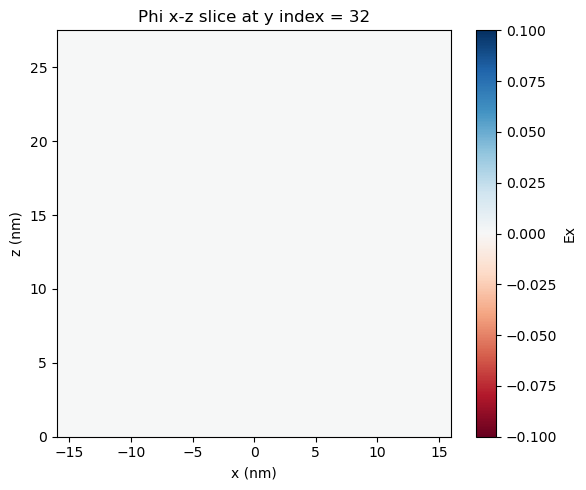

yt : [INFO     ] 2026-06-25 22:41:59,974 Parameters: current_time              = 9.85199999999935e-10
yt : [INFO     ] 2026-06-25 22:41:59,975 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:41:59,975 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:41:59,975 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


Phi_array shape = (64, 64, 59)


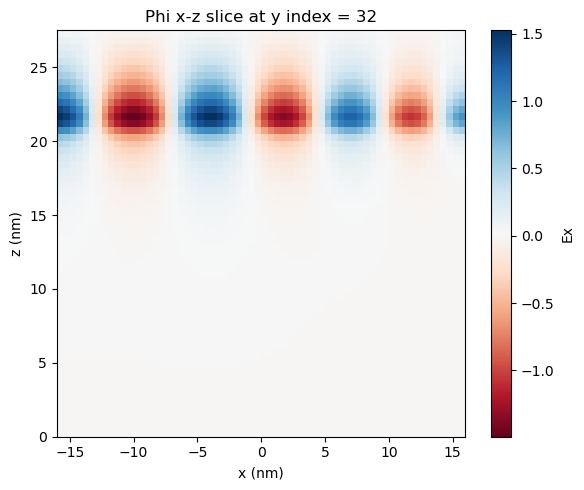

yt : [INFO     ] 2026-06-25 22:42:00,072 Parameters: current_time              = 1.128999999999979e-09
yt : [INFO     ] 2026-06-25 22:42:00,072 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:00,073 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:00,073 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


Phi_array shape = (64, 64, 59)


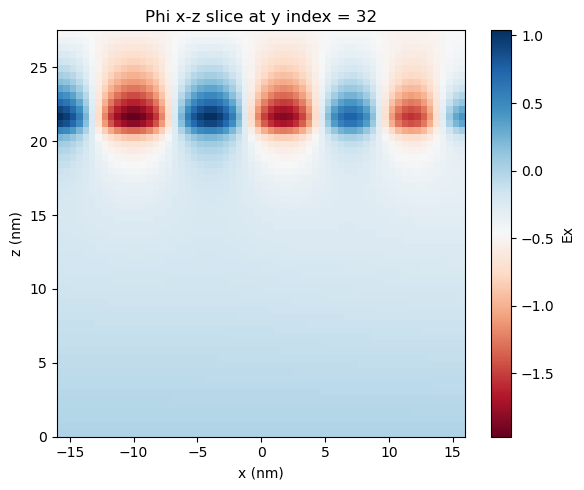

yt : [INFO     ] 2026-06-25 22:42:00,166 Parameters: current_time              = 1.4998000000000928e-09
yt : [INFO     ] 2026-06-25 22:42:00,166 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:00,167 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:00,167 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


Phi_array shape = (64, 64, 59)


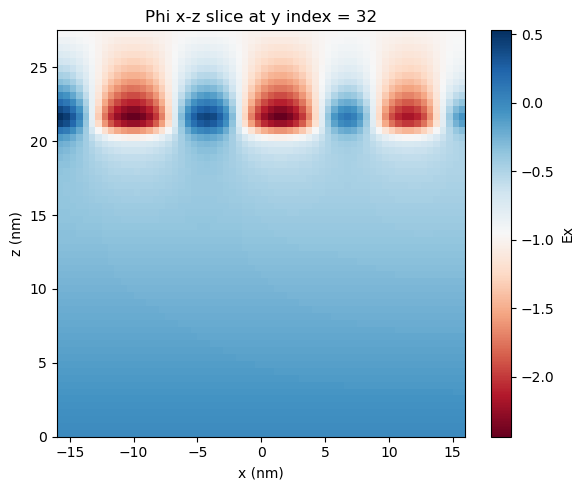

yt : [INFO     ] 2026-06-25 22:42:00,260 Parameters: current_time              = 1.7366000000001654e-09
yt : [INFO     ] 2026-06-25 22:42:00,260 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:00,261 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:00,261 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


Phi_array shape = (64, 64, 59)


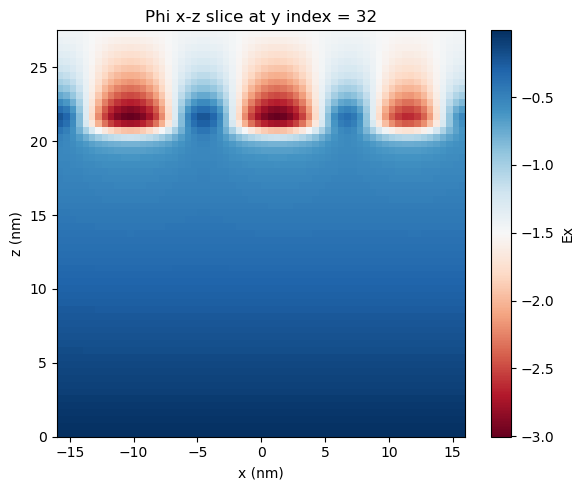

yt : [INFO     ] 2026-06-25 22:42:00,352 Parameters: current_time              = 2.0950000000002754e-09
yt : [INFO     ] 2026-06-25 22:42:00,352 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:00,353 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:00,353 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


Phi_array shape = (64, 64, 59)


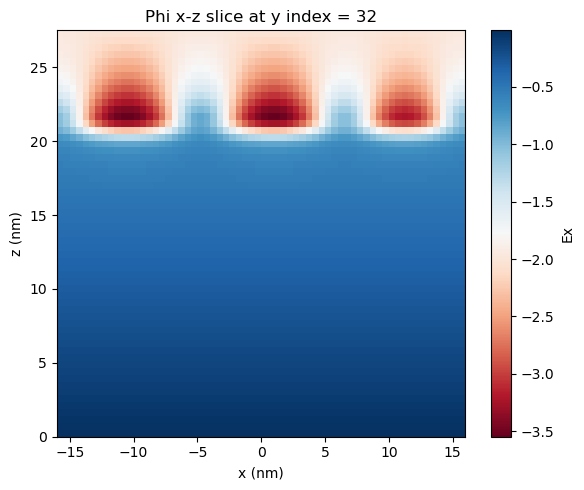

yt : [INFO     ] 2026-06-25 22:42:00,447 Parameters: current_time              = 3.146200000000598e-09
yt : [INFO     ] 2026-06-25 22:42:00,447 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:00,447 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:00,447 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


Phi_array shape = (64, 64, 59)


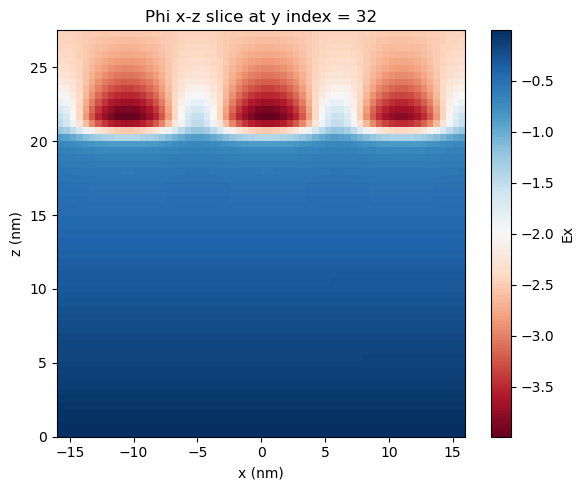

yt : [INFO     ] 2026-06-25 22:42:00,541 Parameters: current_time              = 4.1230000000008974e-09
yt : [INFO     ] 2026-06-25 22:42:00,541 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:00,541 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:00,542 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


Phi_array shape = (64, 64, 59)


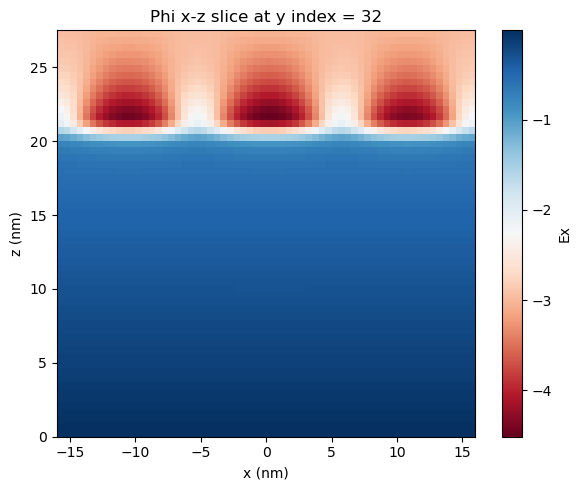

yt : [INFO     ] 2026-06-25 22:42:00,632 Parameters: current_time              = 4.418200000000988e-09
yt : [INFO     ] 2026-06-25 22:42:00,632 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:00,632 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:00,632 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


Phi_array shape = (64, 64, 59)


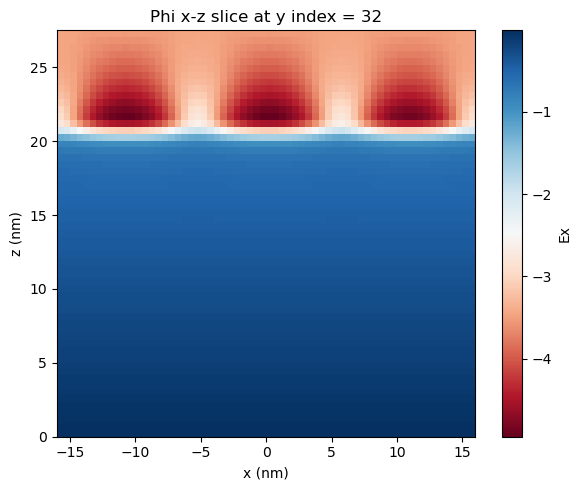

yt : [INFO     ] 2026-06-25 22:42:01,007 Parameters: current_time              = 4.84820000000112e-09
yt : [INFO     ] 2026-06-25 22:42:01,008 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:01,008 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:01,008 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


Phi_array shape = (64, 64, 59)


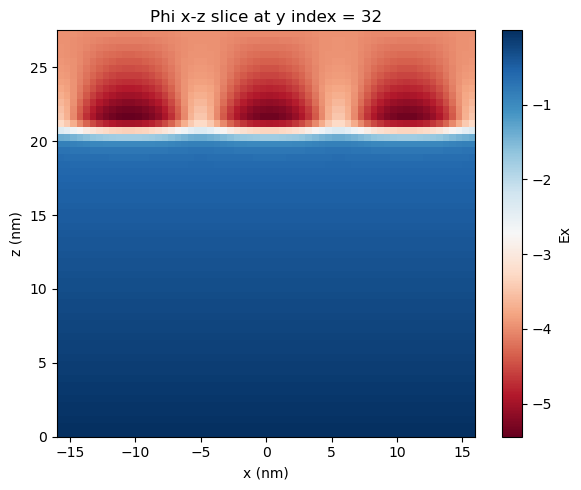

yt : [INFO     ] 2026-06-25 22:42:01,098 Parameters: current_time              = 5.424600000001297e-09
yt : [INFO     ] 2026-06-25 22:42:01,099 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:01,099 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:01,099 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


Phi_array shape = (64, 64, 59)


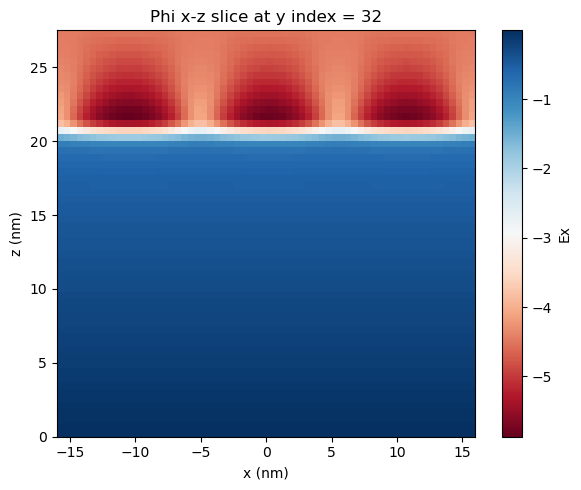

yt : [INFO     ] 2026-06-25 22:42:01,191 Parameters: current_time              = 5.627600000001359e-09
yt : [INFO     ] 2026-06-25 22:42:01,191 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:01,191 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:01,191 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


Phi_array shape = (64, 64, 59)


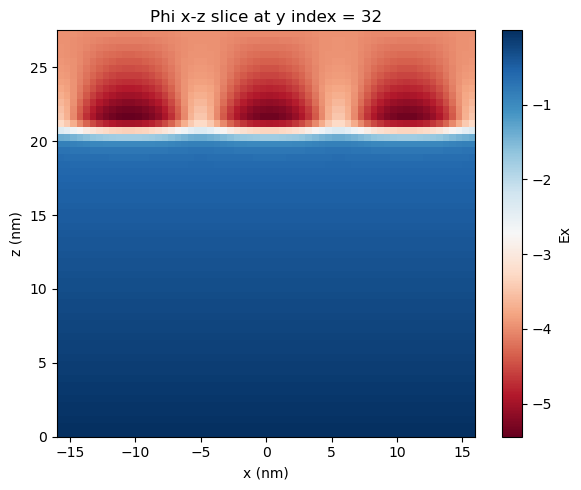

yt : [INFO     ] 2026-06-25 22:42:01,283 Parameters: current_time              = 5.89160000000144e-09
yt : [INFO     ] 2026-06-25 22:42:01,283 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:01,284 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:01,284 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


Phi_array shape = (64, 64, 59)


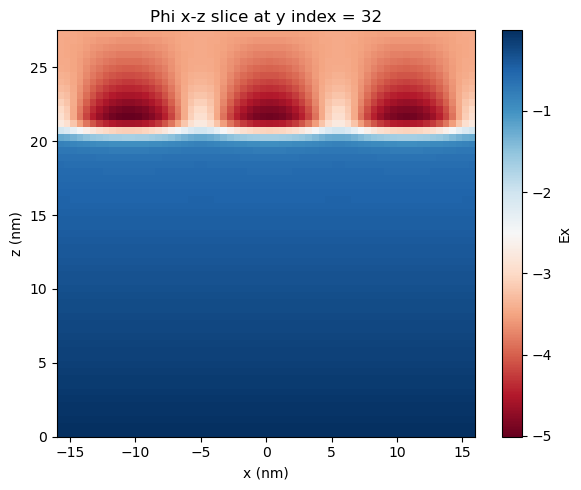

yt : [INFO     ] 2026-06-25 22:42:01,374 Parameters: current_time              = 6.262800000001554e-09
yt : [INFO     ] 2026-06-25 22:42:01,374 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:01,374 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:01,374 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


Phi_array shape = (64, 64, 59)


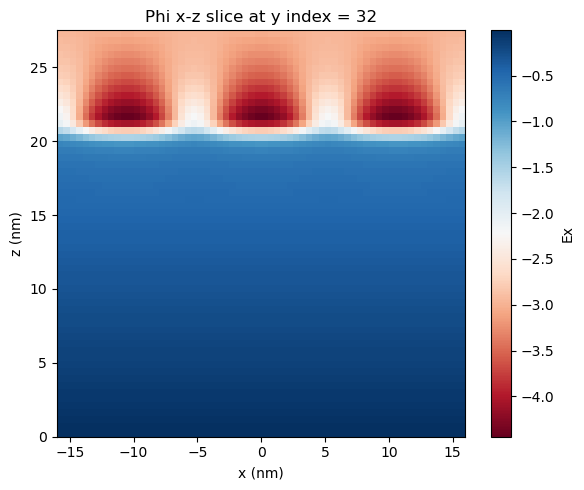

yt : [INFO     ] 2026-06-25 22:42:01,468 Parameters: current_time              = 6.395200000001594e-09
yt : [INFO     ] 2026-06-25 22:42:01,469 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:01,469 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:01,469 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


Phi_array shape = (64, 64, 59)


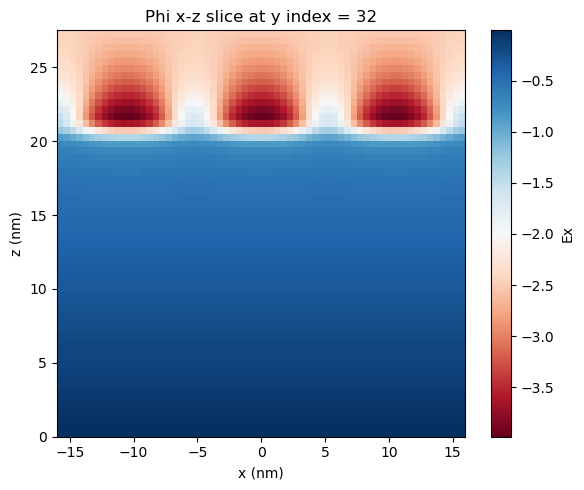

yt : [INFO     ] 2026-06-25 22:42:01,562 Parameters: current_time              = 6.711200000001691e-09
yt : [INFO     ] 2026-06-25 22:42:01,562 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:01,562 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:01,563 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


Phi_array shape = (64, 64, 59)


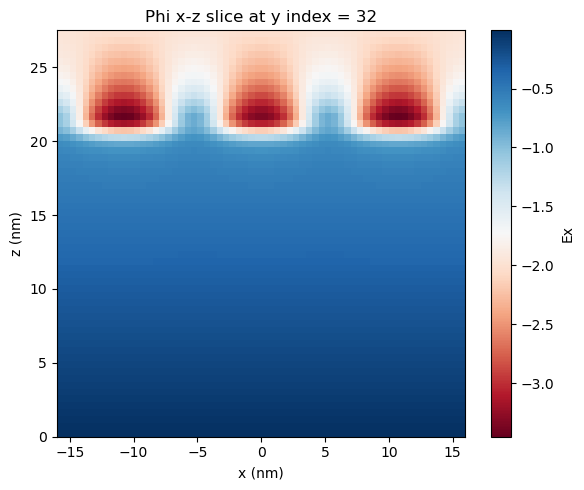

yt : [INFO     ] 2026-06-25 22:42:01,655 Parameters: current_time              = 6.982800000001775e-09
yt : [INFO     ] 2026-06-25 22:42:01,655 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:01,655 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:01,655 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


Phi_array shape = (64, 64, 59)


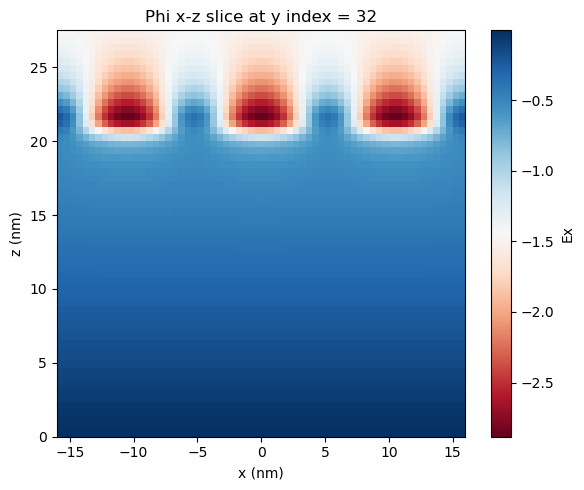

yt : [INFO     ] 2026-06-25 22:42:01,746 Parameters: current_time              = 7.110600000001814e-09
yt : [INFO     ] 2026-06-25 22:42:01,746 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:01,747 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:01,747 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


Phi_array shape = (64, 64, 59)


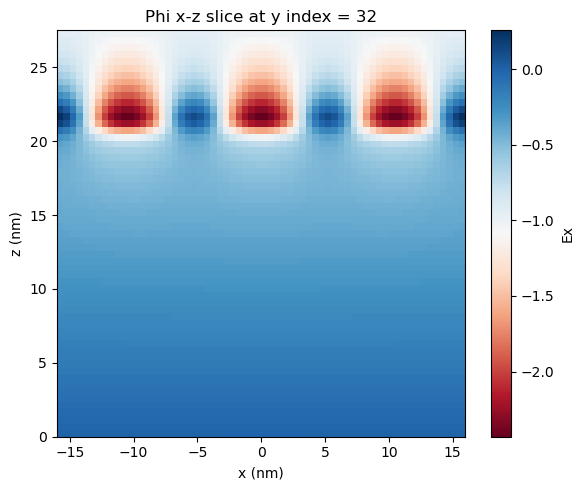

yt : [INFO     ] 2026-06-25 22:42:01,845 Parameters: current_time              = 7.317400000001877e-09
yt : [INFO     ] 2026-06-25 22:42:01,845 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:01,846 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:01,846 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


Phi_array shape = (64, 64, 59)


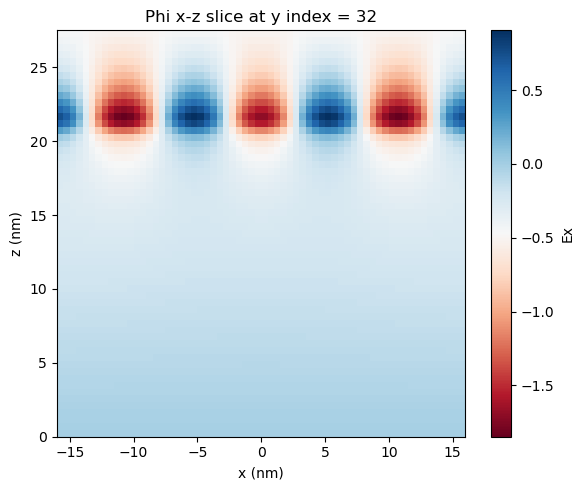

yt : [INFO     ] 2026-06-25 22:42:01,940 Parameters: current_time              = 7.407600000001905e-09
yt : [INFO     ] 2026-06-25 22:42:01,941 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:01,941 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:01,941 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


Phi_array shape = (64, 64, 59)


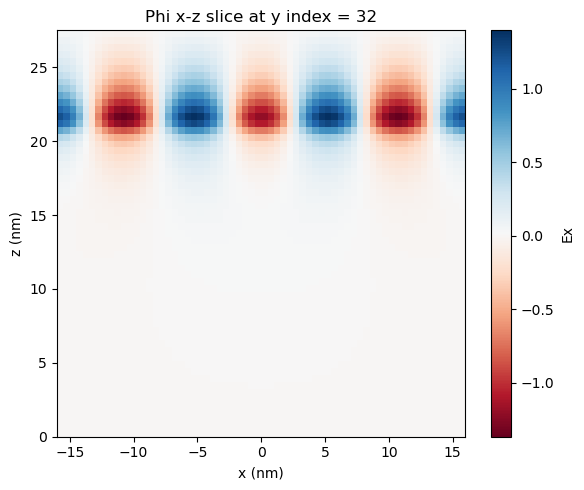

yt : [INFO     ] 2026-06-25 22:42:02,033 Parameters: current_time              = 7.53080000000161e-09
yt : [INFO     ] 2026-06-25 22:42:02,034 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:02,034 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:02,034 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


Phi_array shape = (64, 64, 59)


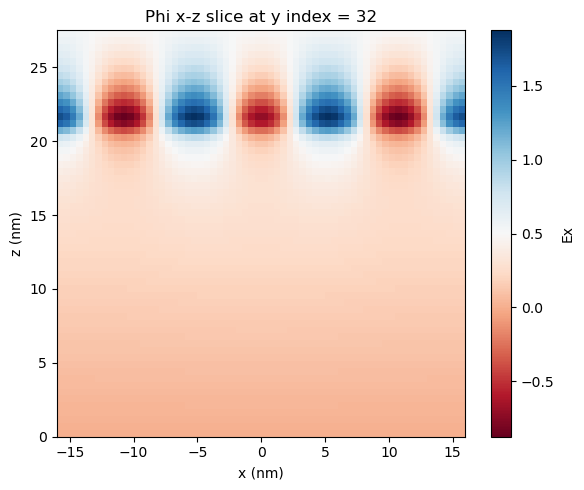

yt : [INFO     ] 2026-06-25 22:42:02,123 Parameters: current_time              = 7.70600000000094e-09
yt : [INFO     ] 2026-06-25 22:42:02,123 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:02,124 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:02,124 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


Phi_array shape = (64, 64, 59)


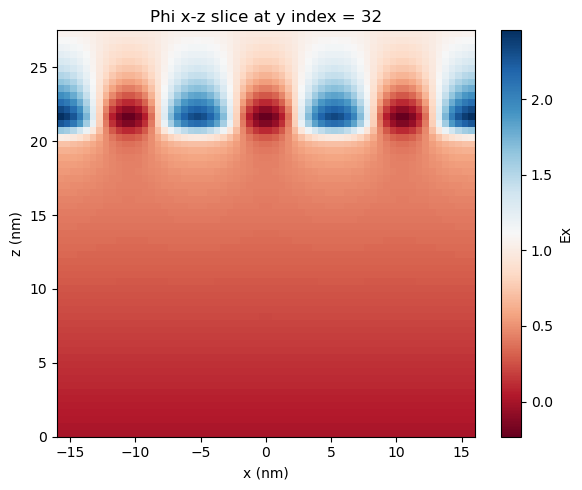

yt : [INFO     ] 2026-06-25 22:42:02,214 Parameters: current_time              = 8.01659999999975e-09
yt : [INFO     ] 2026-06-25 22:42:02,214 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:02,215 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:02,215 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


Phi_array shape = (64, 64, 59)


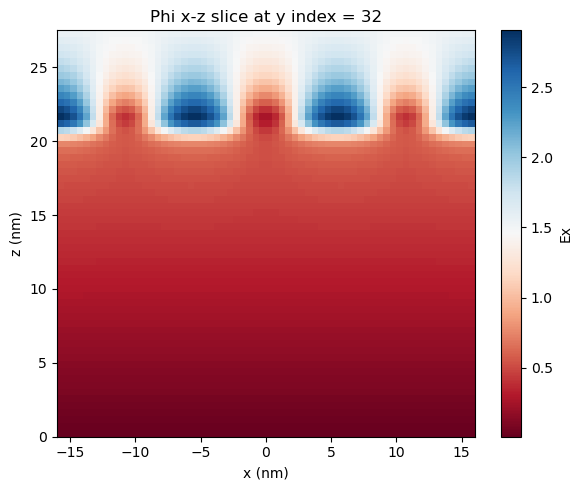

yt : [INFO     ] 2026-06-25 22:42:02,305 Parameters: current_time              = 8.479999999997976e-09
yt : [INFO     ] 2026-06-25 22:42:02,305 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:02,306 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:02,306 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


Phi_array shape = (64, 64, 59)


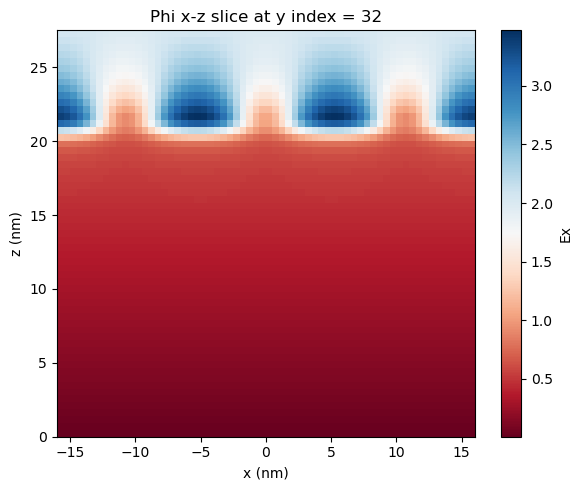

yt : [INFO     ] 2026-06-25 22:42:02,643 Parameters: current_time              = 8.810799999996709e-09
yt : [INFO     ] 2026-06-25 22:42:02,643 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:02,644 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:02,644 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


Phi_array shape = (64, 64, 59)


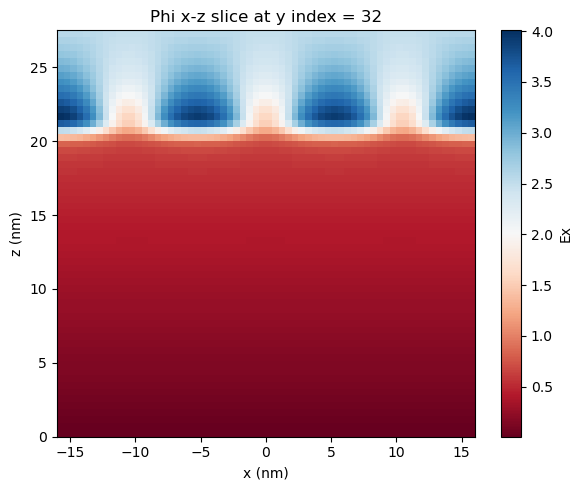

yt : [INFO     ] 2026-06-25 22:42:02,736 Parameters: current_time              = 9.156399999995386e-09
yt : [INFO     ] 2026-06-25 22:42:02,736 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:02,737 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:02,737 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


Phi_array shape = (64, 64, 59)


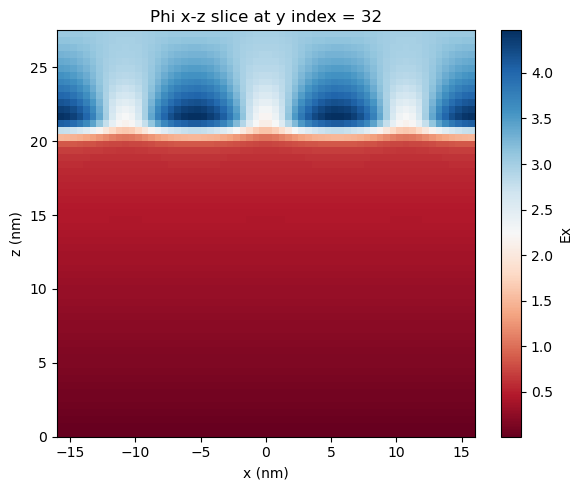

yt : [INFO     ] 2026-06-25 22:42:02,831 Parameters: current_time              = 9.653399999993482e-09
yt : [INFO     ] 2026-06-25 22:42:02,831 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:02,831 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:02,831 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


Phi_array shape = (64, 64, 59)


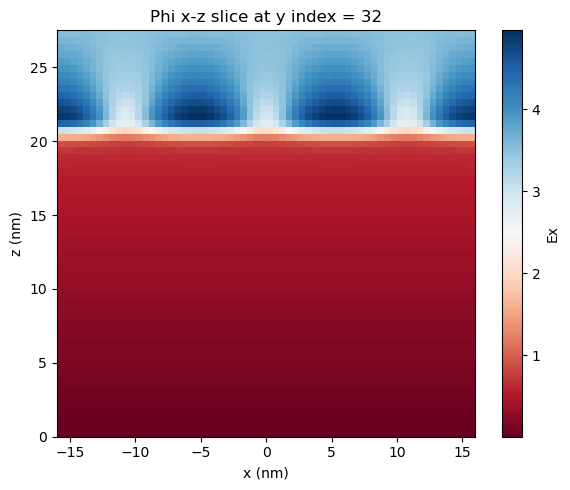

yt : [INFO     ] 2026-06-25 22:42:02,922 Parameters: current_time              = 9.974999999992251e-09
yt : [INFO     ] 2026-06-25 22:42:02,922 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:02,923 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:02,923 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


Phi_array shape = (64, 64, 59)


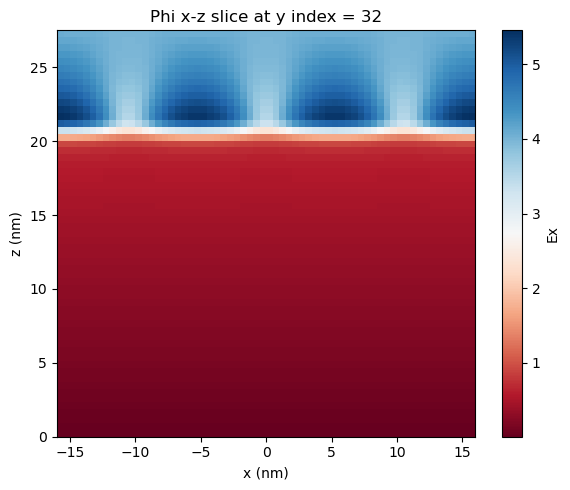

yt : [INFO     ] 2026-06-25 22:42:03,014 Parameters: current_time              = 1.0503799999990226e-08
yt : [INFO     ] 2026-06-25 22:42:03,015 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:03,015 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:03,015 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


Phi_array shape = (64, 64, 59)


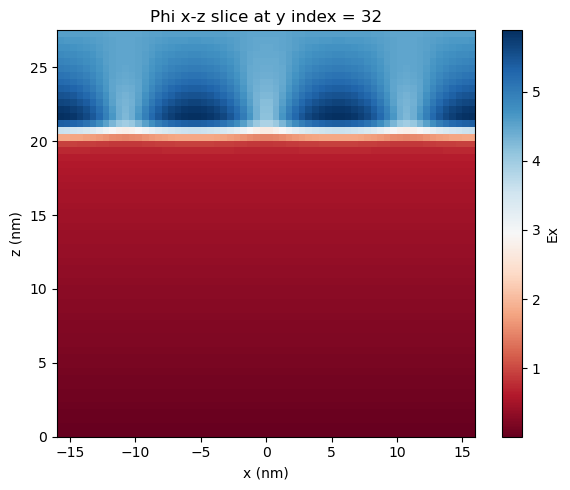

yt : [INFO     ] 2026-06-25 22:42:03,104 Parameters: current_time              = 1.0952799999988507e-08
yt : [INFO     ] 2026-06-25 22:42:03,104 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:03,104 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:03,104 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


Phi_array shape = (64, 64, 59)


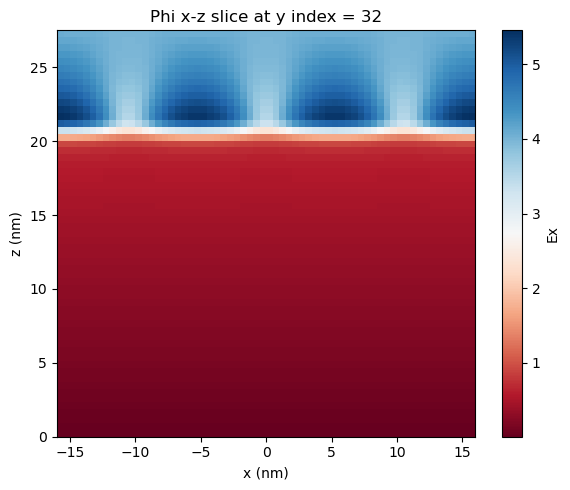

yt : [INFO     ] 2026-06-25 22:42:03,194 Parameters: current_time              = 1.1092399999987972e-08
yt : [INFO     ] 2026-06-25 22:42:03,194 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:03,195 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:03,195 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


Phi_array shape = (64, 64, 59)


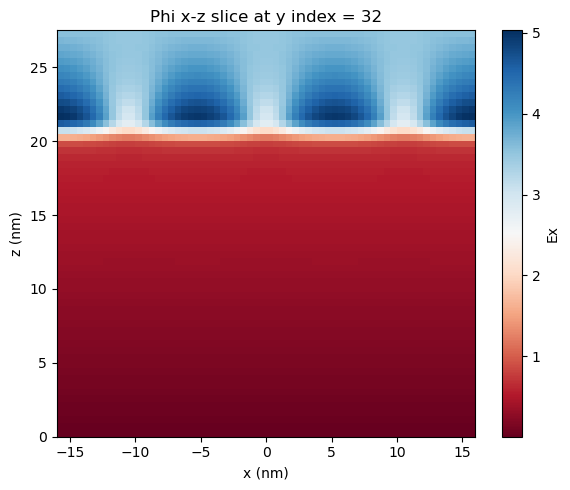

yt : [INFO     ] 2026-06-25 22:42:03,285 Parameters: current_time              = 1.145619999998658e-08
yt : [INFO     ] 2026-06-25 22:42:03,285 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:03,285 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:03,285 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


Phi_array shape = (64, 64, 59)


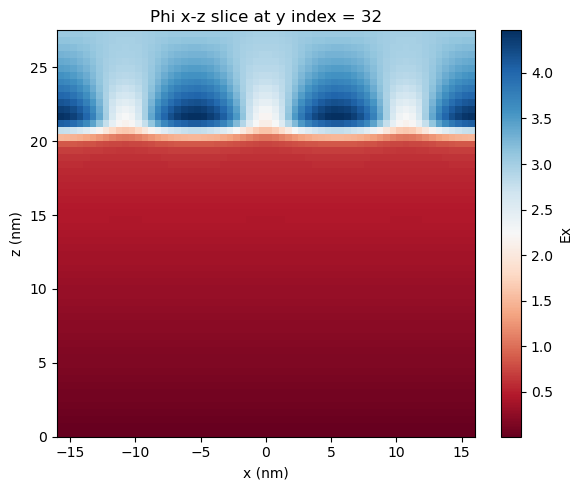

yt : [INFO     ] 2026-06-25 22:42:03,379 Parameters: current_time              = 1.1613599999985976e-08
yt : [INFO     ] 2026-06-25 22:42:03,379 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:03,379 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:03,379 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


Phi_array shape = (64, 64, 59)


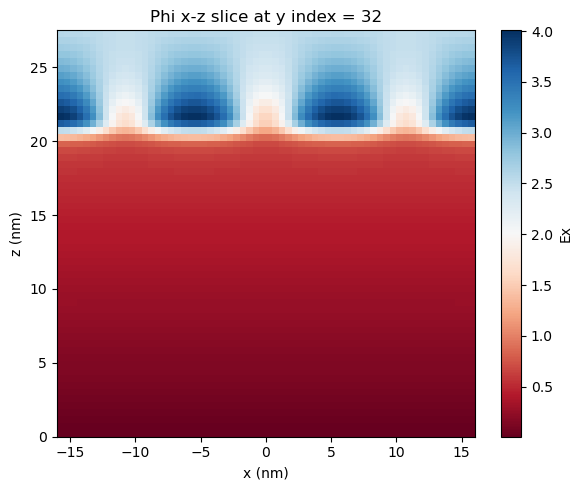

yt : [INFO     ] 2026-06-25 22:42:03,472 Parameters: current_time              = 1.2107999999984083e-08
yt : [INFO     ] 2026-06-25 22:42:03,473 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:03,473 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:03,473 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


Phi_array shape = (64, 64, 59)


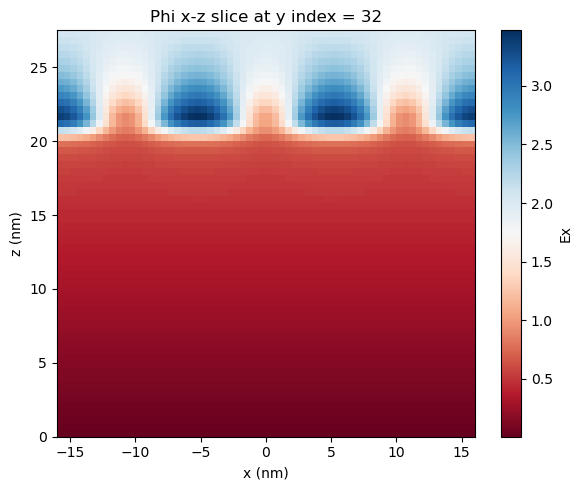

yt : [INFO     ] 2026-06-25 22:42:03,564 Parameters: current_time              = 1.2481799999982652e-08
yt : [INFO     ] 2026-06-25 22:42:03,564 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:03,565 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:03,565 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


Phi_array shape = (64, 64, 59)


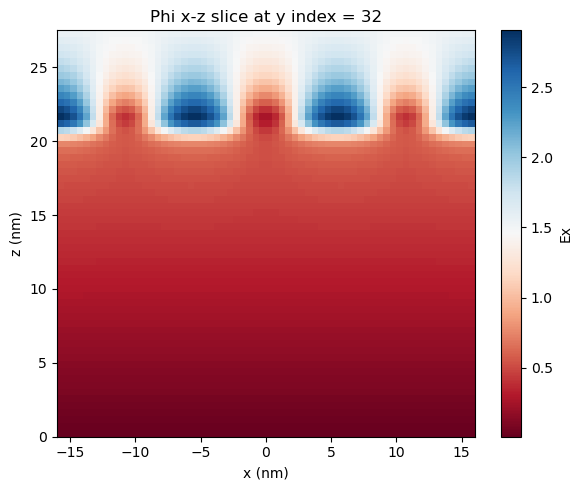

yt : [INFO     ] 2026-06-25 22:42:03,656 Parameters: current_time              = 1.2588799999982242e-08
yt : [INFO     ] 2026-06-25 22:42:03,656 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:03,656 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:03,657 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


Phi_array shape = (64, 64, 59)


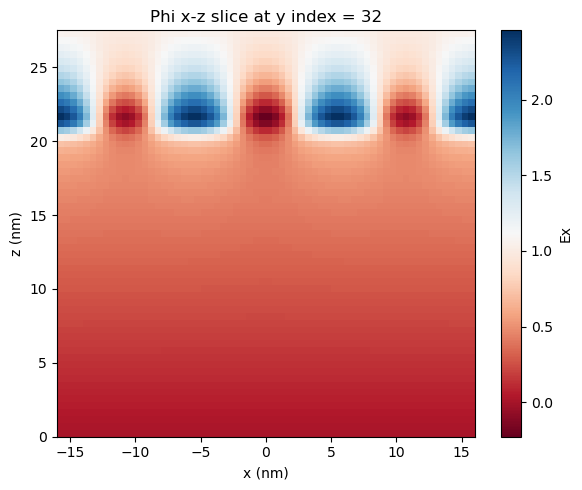

yt : [INFO     ] 2026-06-25 22:42:03,747 Parameters: current_time              = 1.2820399999981355e-08
yt : [INFO     ] 2026-06-25 22:42:03,748 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:03,748 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:03,748 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


Phi_array shape = (64, 64, 59)


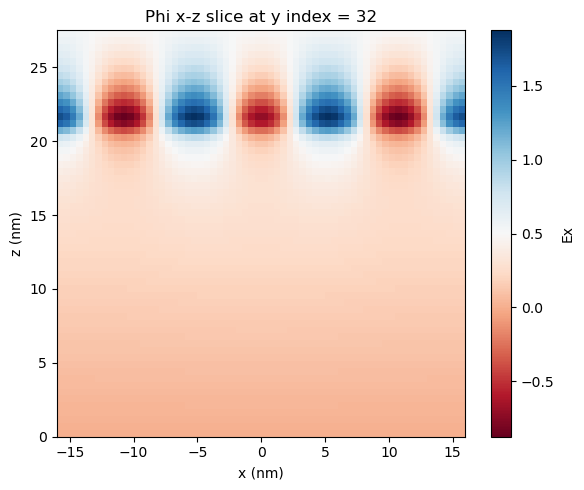

yt : [INFO     ] 2026-06-25 22:42:03,837 Parameters: current_time              = 1.2913399999981e-08
yt : [INFO     ] 2026-06-25 22:42:03,837 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:03,838 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:03,838 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


Phi_array shape = (64, 64, 59)


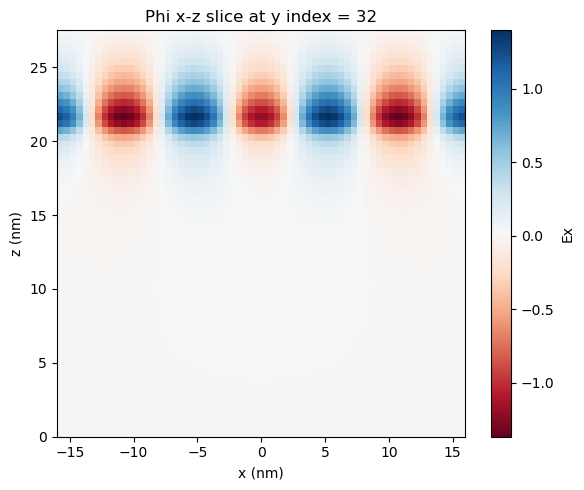

yt : [INFO     ] 2026-06-25 22:42:03,928 Parameters: current_time              = 1.3027199999980564e-08
yt : [INFO     ] 2026-06-25 22:42:03,928 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:03,929 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:03,929 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


Phi_array shape = (64, 64, 59)


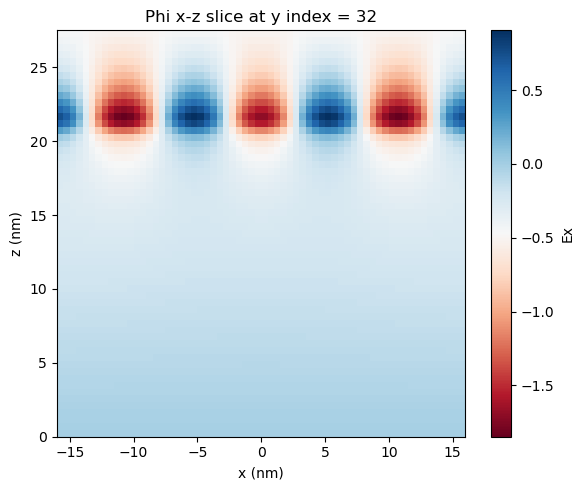

yt : [INFO     ] 2026-06-25 22:42:04,288 Parameters: current_time              = 1.3206799999979876e-08
yt : [INFO     ] 2026-06-25 22:42:04,288 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:04,288 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:04,289 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


Phi_array shape = (64, 64, 59)


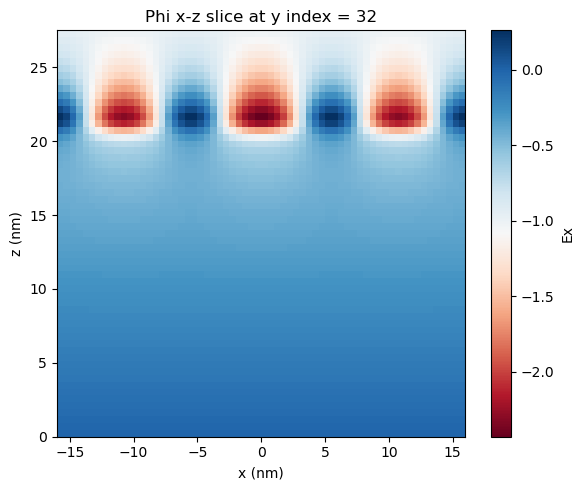

yt : [INFO     ] 2026-06-25 22:42:04,383 Parameters: current_time              = 1.3574999999978466e-08
yt : [INFO     ] 2026-06-25 22:42:04,384 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:04,384 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:04,384 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


Phi_array shape = (64, 64, 59)


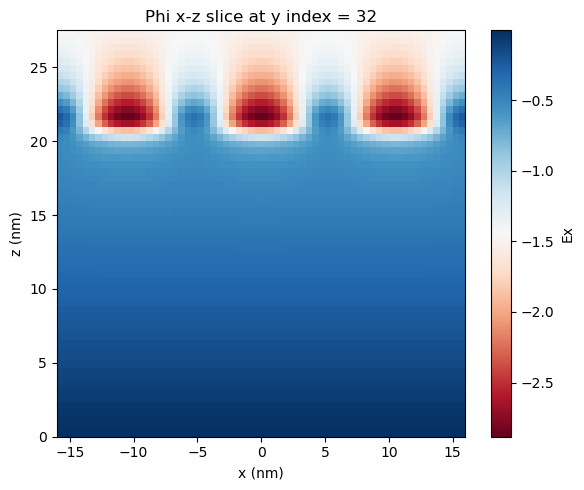

yt : [INFO     ] 2026-06-25 22:42:04,478 Parameters: current_time              = 1.3868599999977342e-08
yt : [INFO     ] 2026-06-25 22:42:04,478 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:04,479 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:04,479 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


Phi_array shape = (64, 64, 59)


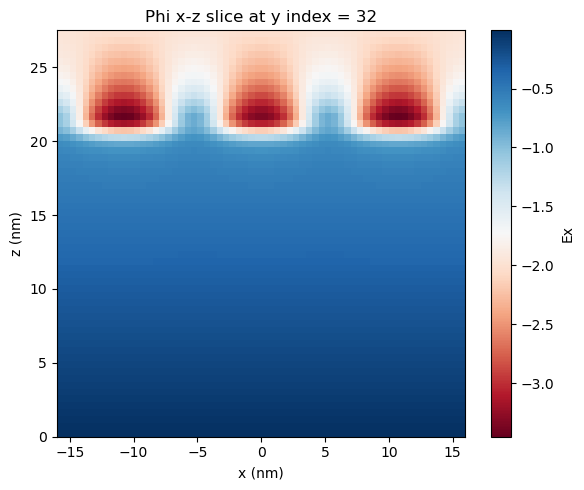

yt : [INFO     ] 2026-06-25 22:42:04,574 Parameters: current_time              = 1.4160799999976223e-08
yt : [INFO     ] 2026-06-25 22:42:04,574 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:04,574 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:04,574 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


Phi_array shape = (64, 64, 59)


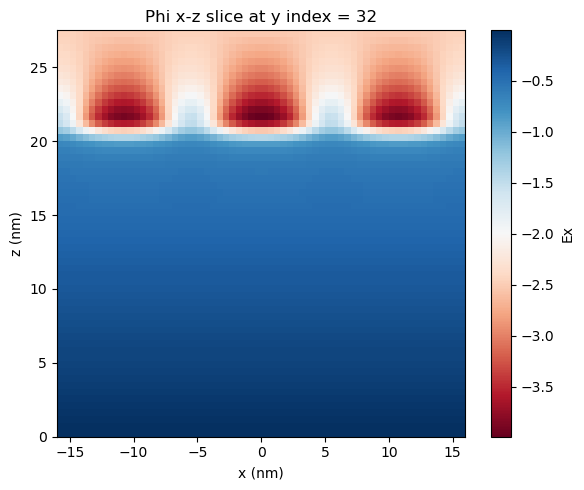

yt : [INFO     ] 2026-06-25 22:42:04,669 Parameters: current_time              = 1.4485799999974978e-08
yt : [INFO     ] 2026-06-25 22:42:04,669 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:04,669 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:04,670 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


Phi_array shape = (64, 64, 59)


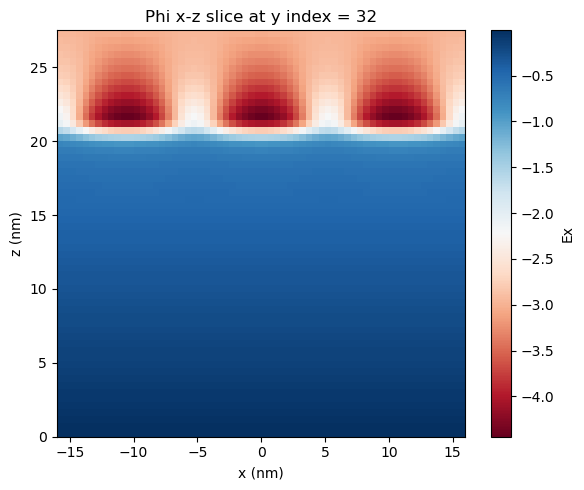

yt : [INFO     ] 2026-06-25 22:42:04,765 Parameters: current_time              = 1.4839999999973622e-08
yt : [INFO     ] 2026-06-25 22:42:04,765 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:04,766 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:04,766 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


Phi_array shape = (64, 64, 59)


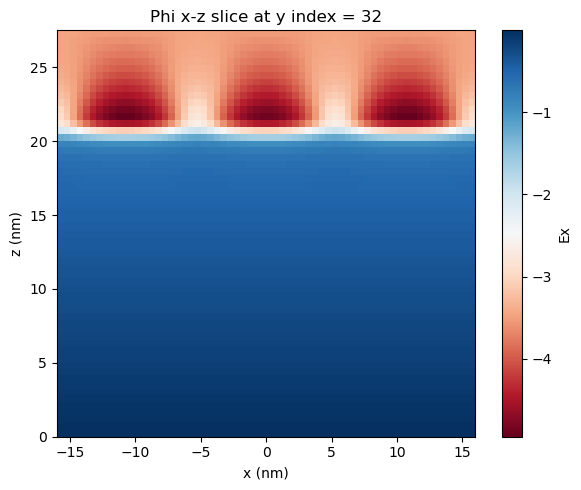

yt : [INFO     ] 2026-06-25 22:42:04,855 Parameters: current_time              = 1.5156599999974522e-08
yt : [INFO     ] 2026-06-25 22:42:04,856 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:04,856 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:04,856 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


Phi_array shape = (64, 64, 59)


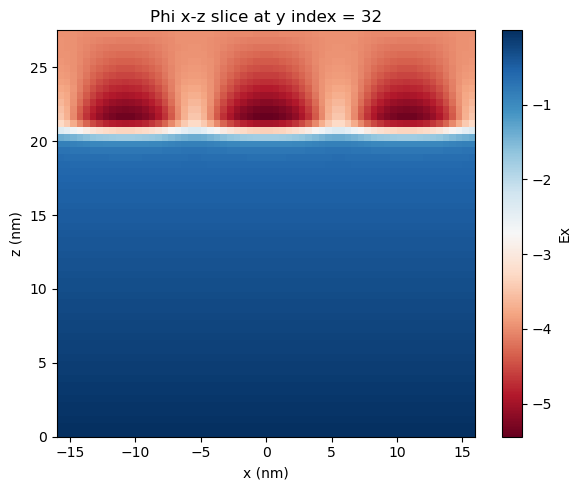

yt : [INFO     ] 2026-06-25 22:42:04,948 Parameters: current_time              = 1.570739999997697e-08
yt : [INFO     ] 2026-06-25 22:42:04,948 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:04,948 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:04,948 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


Phi_array shape = (64, 64, 59)


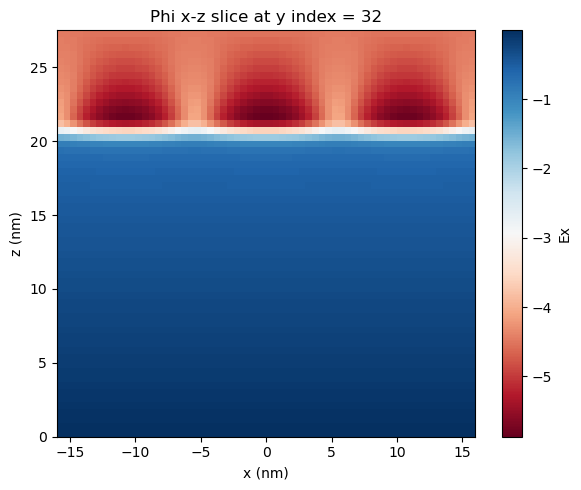

In [32]:
import yt
import numpy as np
import matplotlib.pyplot as plt
for i in range(len(plot_names)):
    plotfile = PLOT_DIR/plot_names[i] 
    field = ("boxlib", "Phi")

    ds = yt.load(plotfile)

    #g = ds.index.grids[0] # 先看 grid 0，多個 grid 的話要自己想辦法合併資料
    Phi_array = read_full_field_from_grids(ds, field) # 讀取整個 domain 的 Phi 資料，會自動合併多個 grid

    print("Phi_array shape =", Phi_array.shape)

    Nx, Ny, Nz = Phi_array.shape #用index存資料

    lo = ds.domain_left_edge.to_value()
    hi = ds.domain_right_edge.to_value()
    dims = np.array([Nx, Ny, Nz])

    dx = (hi - lo) / dims

    x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9 #index對應空間位置
    z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

    y0 = Ny // 2
    slice2d = Phi_array[:, y0, :]

    plt.figure(figsize=(6, 5))
    im = plt.pcolormesh(
        x_nm,
        z_nm,
        slice2d.T,
        shading="auto",
        cmap="RdBu"
    )

    plt.colorbar(im, label="Ex")
    plt.xlabel("x (nm)")
    plt.ylabel("z (nm)")
    plt.title(f"Phi x-z slice at y index = {y0}")
    plt.tight_layout()
    plt.show()

yt : [INFO     ] 2026-06-25 19:50:42,168 Parameters: current_time              = 7.28999999999961e-10
yt : [INFO     ] 2026-06-25 19:50:42,168 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:50:42,168 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:50:42,168 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


E_array shape = (64, 64, 59)


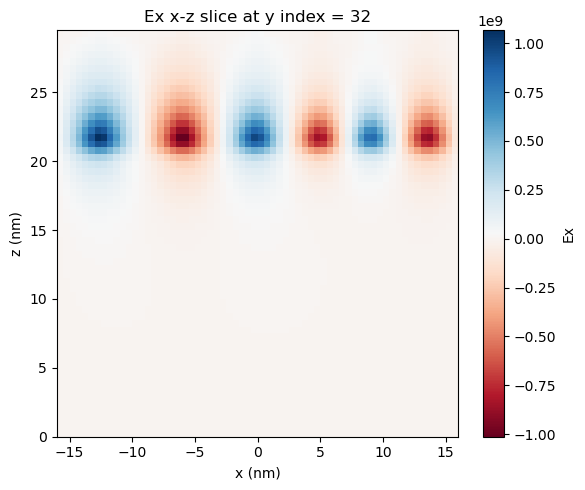

In [21]:
import yt
import numpy as np
import matplotlib.pyplot as plt

#PLOT_DIR = Path("/home/kaiwi/FAM/FerroX/Exec/MFIS_t_8_plt")  # 改成你 plotfile 所在的資料夾
plotfile = PLOT_DIR/plot_names[2] 
field = ("boxlib", "Ex")

ds = yt.load(plotfile)

#g = ds.index.grids[0] # 先看 grid 0，多個 grid 的話要自己想辦法合併資料
E_array = read_full_field_from_grids(ds, field) # 讀取整個 domain 的 Ex 資料，會自動合併多個 grid

print("E_array shape =", E_array.shape)

Nx, Ny, Nz = E_array.shape #用index存資料

lo = ds.domain_left_edge.to_value()
hi = ds.domain_right_edge.to_value()
dims = np.array([Nx, Ny, Nz])

dx = (hi - lo) / dims

x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9 #index對應空間位置
z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

y0 = Ny // 2
slice2d = E_array[:, y0, :]

plt.figure(figsize=(6, 5))
im = plt.pcolormesh(
    x_nm,
    z_nm,
    slice2d.T,
    shading="auto",
    cmap="RdBu"
)

plt.colorbar(im, label="Ex")
plt.xlabel("x (nm)")
plt.ylabel("z (nm)")
plt.title(f"Ex x-z slice at y index = {y0}")
plt.tight_layout()
plt.show()

## 2D Pz slice plot(all voltage in same graph)

yt : [INFO     ] 2026-06-25 22:42:52,350 Parameters: current_time              = 5.424600000001297e-09
yt : [INFO     ] 2026-06-25 22:42:52,350 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:52,350 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:52,350 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


yt : [INFO     ] 2026-06-25 22:42:52,394 Parameters: current_time              = 5.627600000001359e-09
yt : [INFO     ] 2026-06-25 22:42:52,394 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:52,394 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:52,395 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]
yt : [INFO     ] 2026-06-25 22:42:52,436 Parameters: current_time              = 5.89160000000144e-09
yt : [INFO     ] 2026-06-25 22:42:52,436 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:52,436 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:52,436 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]
yt : [INFO     ] 2026-06-25 22:42:52,477 Parameters: current_time              = 6.262800000001554e-09
yt : [INFO     ] 2026-06-25 22:42:52,477 Parameters: domain_dimensio

Plotfiles to draw:
  plt00027123
  plt00028138
  plt00029458
  plt00031314
  plt00031976
  plt00033556
  plt00034914
  plt00035553
  plt00036587
  plt00037038
  plt00037654
  plt00038530
  plt00040083
  plt00042400
  plt00044054
  plt00045782
  plt00048267
  plt00049875
  plt00052519
  plt00054764
  plt00055462
  plt00057281
  plt00058068
  plt00060540
  plt00062409
  plt00062944
  plt00064102
  plt00064567
  plt00065136
  plt00066034
  plt00067875
  plt00069343
  plt00070804
  plt00072429
  plt00074200
  plt00075783
  plt00078537
37 number of plotfiles will be drawn after filtering.


yt : [INFO     ] 2026-06-25 22:42:52,560 Parameters: current_time              = 6.711200000001691e-09
yt : [INFO     ] 2026-06-25 22:42:52,560 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:52,560 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:52,560 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]
yt : [INFO     ] 2026-06-25 22:42:52,602 Parameters: current_time              = 6.982800000001775e-09
yt : [INFO     ] 2026-06-25 22:42:52,602 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:42:52,602 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:42:52,602 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]
yt : [INFO     ] 2026-06-25 22:42:52,644 Parameters: current_time              = 7.110600000001814e-09
yt : [INFO     ] 2026-06-25 22:42:52,644 Parameters: domain_dimensi

Drawing 37 plots after filtering.
Saved figure: ./figs/Pz_FE_layer_stack.png


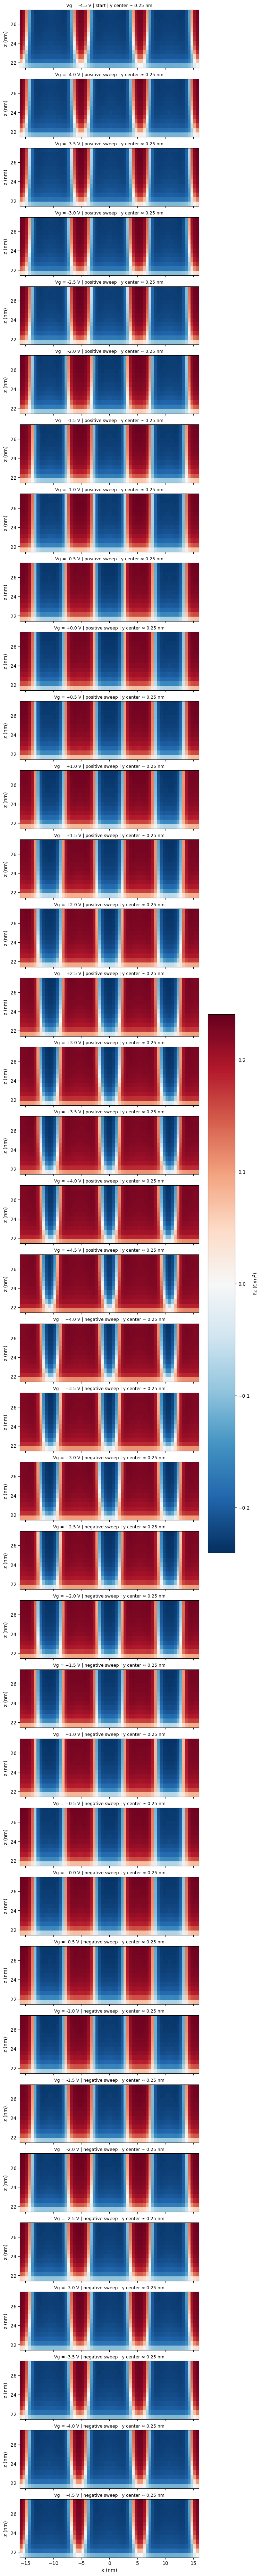

In [33]:
from pathlib import Path
import re

import yt
import numpy as np
import matplotlib.pyplot as plt


# ==========================
# User settings
# ==========================

#PLOT_DIR = Path("/home/kaiwi/FAM/FerroX/Exec")          # plotfile 所在資料夾
P_FIELD = ("boxlib", "Pz")
PHI_FIELD = ("boxlib", "Phi")

# ==========================
# Selection list (NEW)
# ==========================
# format: (voltage, direction)
# voltage 用 None 表示 wildcard
# direction 用 None 表示 wildcard
'''
SELECT_LIST = [
    
    (-0.5, "positive sweep"), 
    (-0.5, "negative sweep"),
   
]
'''
SELECT_LIST = None  # 不過濾，全部畫出來
USE_FE_X_RANGE = False

# y slice: None 表示取 y 方向正中間
Y_INDEX = None

# 若 plot_names 已經是你前面整理好的 steady-state plot list，就直接用
# plot_names = [...]
# 若沒有，就自動抓目前資料夾內所有 plt########
AUTO_FIND_PLOTS = False

# 跳過 initial plt00000000
SKIP_INITIAL = True

# 色階是否對稱於 0，畫 Pz 通常建議 True
SYMMETRIC_COLOR_SCALE = False

# 輸出圖片名稱
SAVE_FIG = True
OUT_FIG = "./figs/Pz_FE_layer_stack.png"


# ==========================
# Helper functions
# ==========================


def to_numpy(field_data):
    try:
        return field_data.to_ndarray()
    except AttributeError:
        return field_data.v


def read_one_plot(plotfile, y_index=None):
    ds = yt.load(str(plotfile))
    #g = ds.index.grids[0]

    P = read_full_field_from_grids(ds, P_FIELD) # 讀取整個 domain 的 Pz 資料，會自動合併多個 grid
    P*=-1
    if PHI_FIELD in ds.field_list:
        Phi = read_full_field_from_grids(ds, PHI_FIELD) # 讀取整個 domain 的 Phi 資料，會自動合併多個 grid
    else:
        Phi = None

    Nx, Ny, Nz = P.shape

    lo = ds.domain_left_edge.to_value()
    hi = ds.domain_right_edge.to_value()
    dx = (hi - lo) / np.array([Nx, Ny, Nz])

    x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9
    y_nm = (lo[1] + (np.arange(Ny) + 0.5) * dx[1]) * 1e9
    z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

    if y_index is None:
        y_index = Ny // 2

    # FE z range mask
    z_sel = (z_nm >= FE_Z_LO_NM) & (z_nm <= FE_Z_HI_NM)

    if USE_FE_X_RANGE:
        x_sel = (x_nm >= FE_X_LO_NM) & (x_nm <= FE_X_HI_NM)
    else:
        x_sel = np.ones_like(x_nm, dtype=bool)

    # P slice: shape after selection = (Nx_sel, Nz_sel)
    P_slice = P[np.ix_(x_sel, [y_index], z_sel)][:, 0, :]

    x_plot = x_nm[x_sel]
    z_plot = z_nm[z_sel]

    # 用最上層 cell 的 Phi 平均值當 top potential
    # 注意：這是 top cell center，不是真正 ghost boundary
    if Phi is not None:
        top_phi = Phi[:, :, -1]
        Vtop_mean = float(np.mean(top_phi))
        Vtop_min = float(np.min(top_phi))
        Vtop_max = float(np.max(top_phi))
    else:
        Vtop_mean = np.nan
        Vtop_min = np.nan
        Vtop_max = np.nan

    info = {
        "ds": ds,
        "P_slice": P_slice,
        "x_nm": x_plot,
        "z_nm": z_plot,
        "y_index": y_index,
        "y_nm": float(y_nm[y_index]),
        "Vtop_mean": Vtop_mean,
        "Vtop_min": Vtop_min,
        "Vtop_max": Vtop_max,
        "shape": P.shape,
    }

    return info



def match(rec, direction):# FILTER BY SELECT_LIST
    if not SELECT_LIST:
        return True
    V = rec["Vtop_mean"]

    for v_target, d_target in SELECT_LIST:

        ok_v = (v_target is None) or (
            np.isfinite(V) and np.isclose(V, v_target, atol=1e-1)
        )

        ok_d = (d_target is None) or (direction == d_target)

        if ok_v and ok_d:
            return True

    return False

# ==========================
# Main
# ==========================

if AUTO_FIND_PLOTS:
    plot_names_use = find_plot_names(PLOT_DIR)
else:
    plot_names_use = list(plot_names)

# sort by step if names are plt########
plot_names_use = sorted(plot_names_use, key=lambda n: get_step_from_name(n) if get_step_from_name(n) is not None else 10**99)

if SKIP_INITIAL:
    plot_names_use = [
        n for n in plot_names_use
        if get_step_from_name(n) != 0
    ]

#忽略第一段
plot_names_use = plot_names_use[9:]
    
print("Plotfiles to draw:")
for n in plot_names_use:
    print(" ", n)
print(len(plot_names_use), "number of plotfiles will be drawn after filtering.")

records = []
all_values = []

for name in plot_names_use:
    plotfile = PLOT_DIR / name
    info = read_one_plot(plotfile, y_index=Y_INDEX)

    step = get_step_from_name(name)

    records.append({
        "name": name,
        "step": step,
        **info,
    })

    all_values.append(info["P_slice"])

# shared color scale
all_concat = np.concatenate([v.ravel() for v in all_values])
if SYMMETRIC_COLOR_SCALE:
    vmax = np.nanmax(np.abs(all_concat))
    vmin = -vmax
else:
    vmin = np.nanmin(all_concat)
    vmax = np.nanmax(all_concat)

# determine sweep direction from Vtop sequence
Vseq = np.array([r["Vtop_mean"] for r in records], dtype=float)

directions = []
for idx, V in enumerate(Vseq):
    if idx == 0 or not np.isfinite(Vseq[idx-1]) or not np.isfinite(V):
        directions.append("start")
    else:
        dV = V - Vseq[idx-1]
        if dV > 1e-8:
            directions.append("positive sweep")
        elif dV < -1e-8:
            directions.append("negative sweep")
        else:
            directions.append("same V")

filtered_records = []
filtered_directions = []

for rec, d in zip(records, directions):
    if match(rec, d):
        filtered_records.append(rec)
        filtered_directions.append(d)

records = filtered_records
directions = filtered_directions

# figure size
n = len(records)
print(f"Drawing {n} plots after filtering.")
fig_height = max(2.0 * n, 4.0)
fig, axes = plt.subplots(
    nrows=n,
    ncols=1,
    figsize=(7.5, fig_height),
    sharex=True,
    constrained_layout=True
)


if n == 1:
    axes = [axes]

last_im = None

for ax, rec, sweep_dir in zip(axes, records, directions):
    P_slice = rec["P_slice"]
    x_nm = rec["x_nm"]
    z_nm = rec["z_nm"]

    last_im = ax.pcolormesh(
        x_nm,
        z_nm,
        P_slice.T,
        shading="auto",
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax
    )

    Vmean = rec["Vtop_mean"]
    Vmin = rec["Vtop_min"]
    Vmax = rec["Vtop_max"]

    if np.isfinite(Vmean):
        v_label = f"Vg = {Vmean:+.1f} V"
        # 若你想檢查 top x/y variation，也可以顯示 min/max
        # v_label += f" [{Vmin:+.3f}, {Vmax:+.3f}]"
    else:
        v_label = "Vtop unavailable"

    step_label = f"step={rec['step']}" if rec["step"] is not None else rec["name"]

    ax.set_ylabel("z (nm)")

    ax.set_title(
        f"{v_label} | {sweep_dir} | "
        f"y center ≈ {rec['y_nm']:.2f} nm",
        fontsize=9
    )

axes[-1].set_xlabel("x (nm)")
axes[-1].tick_params(axis='x', labelbottom=True)
'''
for ax in axes:
    ax.set_xlabel("x (nm)")
    ax.tick_params(axis='x', labelbottom=True)
'''
cbar = fig.colorbar(last_im, ax=axes, shrink=0.8)
cbar.set_label(r"Pz (C/m$^2$)")

if SAVE_FIG:
    fig.savefig(OUT_FIG, dpi=200)
    print(f"Saved figure: {OUT_FIG}")

plt.show()

## PV

### User Settings

In [22]:
from pathlib import Path
import re

import yt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ==========================
# User settings
# ==========================

#PLOT_DIR = Path("/home/kaiwi/FAM/FerroX/Exec/MFIS_t_8_1_plt")

P_FIELD = ("boxlib", "Pz")
PHI_FIELD = ("boxlib", "Phi")


# 如果 FE 是全幅 MFIS，通常不用限制 x/y
USE_FE_X_RANGE = False


USE_FE_Y_RANGE = False
# 若你已經有 steady-state plot_names，就用 AUTO_FIND_PLOTS=False
# plot_names = [...]
AUTO_FIND_PLOTS = True

# 如果沒有 plot_names，可以自動找所有 plt########
# 但建議最好只用 steady-state plotfiles
SKIP_INITIAL = True

OUT_CSV = "./figs/MFIS_PV_curve.csv"
OUT_FIG = "./figs/MFIS_PV_curve.png"


### Utils

In [23]:
# ==========================
# Helper functions
# ==========================

def get_step_from_name(name):
    m = re.fullmatch(r"plt(\d+)", str(name))
    return int(m.group(1)) if m else None


def find_plot_names(plot_dir):
    names = []
    for p in plot_dir.iterdir():
        if p.is_dir() and re.fullmatch(r"plt\d+", p.name):
            names.append(p.name)
    names.sort(key=lambda n: get_step_from_name(n))
    return names


def to_numpy(field_data):
    try:
        return field_data.to_ndarray()
    except AttributeError:
        return field_data.v

def read_full_field_from_grids(ds, field):
    """
    Read a cell-centered AMReX field from all yt grids
    and stitch them into one full-domain numpy array.

    Return:
        full: numpy array with shape ds.domain_dimensions
    """
    dims = np.array(ds.domain_dimensions, dtype=int)
    full = np.empty(tuple(dims), dtype=float)

    domain_lo = ds.domain_left_edge.to_value()
    domain_hi = ds.domain_right_edge.to_value()
    dx = (domain_hi - domain_lo) / dims

    for grid in ds.index.grids:
        arr = to_numpy(grid[field])

        left = grid.LeftEdge.to_value()

        # grid start index in global domain
        start = np.rint((left - domain_lo) / dx).astype(int)

        nx, ny, nz = arr.shape
        i0, j0, k0 = start
        i1, j1, k1 = i0 + nx, j0 + ny, k0 + nz

        full[i0:i1, j0:j1, k0:k1] = arr

    return full

def read_pv_from_plot(plotfile):
    ds = yt.load(str(plotfile))
    Pz = read_full_field_from_grids(ds, P_FIELD)
    Phi = read_full_field_from_grids(ds, PHI_FIELD)

    Nx, Ny, Nz = Pz.shape
    print(f"Read Pz with shape {Pz.shape} from {plotfile}")

    lo = ds.domain_left_edge.to_value()
    hi = ds.domain_right_edge.to_value()
    print(f"Domain: x [{lo[0]:.3e}, {hi[0]:.3e}] m, "
          f"y [{lo[1]:.3e}, {hi[1]:.3e}] m, "
          f"z [{lo[2]:.3e}, {hi[2]:.3e}] m")
    dx = (hi - lo) / np.array([Nx, Ny, Nz])

    x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9
    y_nm = (lo[1] + (np.arange(Ny) + 0.5) * dx[1]) * 1e9
    z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

    z_sel = (z_nm >= FE_Z_LO_NM) & (z_nm <= FE_Z_HI_NM)

    if USE_FE_X_RANGE:
        x_sel = (x_nm >= FE_X_LO_NM) & (x_nm <= FE_X_HI_NM)
    else:
        x_sel = np.ones_like(x_nm, dtype=bool)

    if USE_FE_Y_RANGE:
        y_sel = (y_nm >= FE_Y_LO_NM) & (y_nm <= FE_Y_HI_NM)
    else:
        y_sel = np.ones_like(y_nm, dtype=bool)

    Pz_FE = Pz[np.ix_(x_sel, y_sel, z_sel)]

    P_mean = float(np.mean(Pz_FE))
    P_min = float(np.min(Pz_FE))
    P_max = float(np.max(Pz_FE))
    P_std = float(np.std(Pz_FE))

    # 用最上層 cell 的 Phi 平均值估 top electrode potential
    # 注意：這是 top cell center，不是真正 ghost boundary
    top_phi = Phi[:, :, -1]
    Vg_mean = float(np.mean(top_phi))
    Vg_min = float(np.min(top_phi))
    Vg_max = float(np.max(top_phi))
    Vg_std = float(np.std(top_phi))

    return {
        "P_mean": P_mean,
        "P_min": P_min,
        "P_max": P_max,
        "P_std": P_std,
        "Vg_mean": Vg_mean,
        "Vg_min": Vg_min,
        "Vg_max": Vg_max,
        "Vg_std": Vg_std,
        "Nx": Nx,
        "Ny": Ny,
        "Nz": Nz,
        "num_FE_cells": int(Pz_FE.size),
    }



### Data Preparation

In [24]:



# ==========================
# Main
# ==========================

if AUTO_FIND_PLOTS:
    print(f"Finding plotfiles in {PLOT_DIR}...")
    plot_names_use = find_plot_names(PLOT_DIR)
else:
    plot_names_use = list(plot_names)

plot_names_use = sorted(
    plot_names_use,
    key=lambda n: get_step_from_name(n) if get_step_from_name(n) is not None else 10**99
)

if SKIP_INITIAL:
    plot_names_use = [
        n for n in plot_names_use
        if get_step_from_name(n) != 0
    ]
plot_names_use = plot_names_use[9:]  # skip first 9 plotfiles
rows = []

print(plot_names_use)

for name in plot_names_use:
    plotfile = PLOT_DIR / name
    step = get_step_from_name(name)

    info = read_pv_from_plot(plotfile)

    rows.append({
        "plotfile": name,
        "step": step,
        **info,
    })

    print(
        f"{name} | step={step} | "
        f"Vg={info['Vg_mean']:+.4f} V | "
        f"<Pz>_FE={info['P_mean']:+.6e}"
    )

df = pd.DataFrame(rows)
df.to_csv(OUT_CSV, index=False)
print(f"Saved CSV: {OUT_CSV}")


# ==========================
# Determine sweep direction
# ==========================

V = df["Vg_mean"].to_numpy()
P = df["P_mean"].to_numpy()


direction = np.zeros_like(V)

for i in range(1, len(V)):
    dV = V[i] - V[i - 1]
    if dV > 1e-8:
        direction[i] = 1   # positive sweep
    elif dV < -1e-8:
        direction[i] = -1  # negative sweep
    else:
        direction[i] = direction[i - 1]

#np.append(direction, direction[-1])  # 複製第一筆到最後

df["sweep_direction"] = direction
df.to_csv(OUT_CSV, index=False)




yt : [INFO     ] 2026-06-25 22:34:23,985 Parameters: current_time              = 5.424600000001297e-09
yt : [INFO     ] 2026-06-25 22:34:23,985 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:34:23,985 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:34:23,985 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]
yt : [INFO     ] 2026-06-25 22:34:24,027 Parameters: current_time              = 5.627600000001359e-09
yt : [INFO     ] 2026-06-25 22:34:24,027 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:34:24,028 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:34:24,028 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]
yt : [INFO     ] 2026-06-25 22:34:24,070 Parameters: current_time              = 5.89160000000144e-09
yt : [INFO     ] 2026-06-25 22:34:24,070 Parameters: domain_dimensio

Finding plotfiles in plts...
['plt00027123', 'plt00028138', 'plt00029458', 'plt00031314', 'plt00031976', 'plt00033556', 'plt00034914', 'plt00035553', 'plt00036587', 'plt00037038', 'plt00037654', 'plt00038530', 'plt00040083', 'plt00042400', 'plt00044054', 'plt00045782', 'plt00048267', 'plt00049875', 'plt00052519', 'plt00054764', 'plt00055462', 'plt00057281', 'plt00058068', 'plt00060540', 'plt00062409', 'plt00062944', 'plt00064102', 'plt00064567', 'plt00065136', 'plt00066034', 'plt00067875', 'plt00069343', 'plt00070804', 'plt00072429', 'plt00074200', 'plt00075783', 'plt00078537']
Read Pz with shape (64, 64, 59) from plts/plt00027123
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.750e-08] m
plt00027123 | step=27123 | Vg=-4.5080 V | <Pz>_FE=+1.136657e-01
Read Pz with shape (64, 64, 59) from plts/plt00028138
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.750e-08] m
plt00028138 | step=28138 | Vg=-4.0094 V | <Pz>_FE=+1.0297

yt : [INFO     ] 2026-06-25 22:34:24,196 Parameters: current_time              = 6.711200000001691e-09
yt : [INFO     ] 2026-06-25 22:34:24,196 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:34:24,197 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:34:24,197 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]
yt : [INFO     ] 2026-06-25 22:34:24,239 Parameters: current_time              = 6.982800000001775e-09
yt : [INFO     ] 2026-06-25 22:34:24,239 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:34:24,239 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:34:24,239 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


Read Pz with shape (64, 64, 59) from plts/plt00031976
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.750e-08] m
plt00031976 | step=31976 | Vg=-2.5035 V | <Pz>_FE=+6.491855e-02
Read Pz with shape (64, 64, 59) from plts/plt00033556
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.750e-08] m
plt00033556 | step=33556 | Vg=-1.9960 V | <Pz>_FE=+4.502681e-02
Read Pz with shape (64, 64, 59) from plts/plt00034914
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.750e-08] m
plt00034914 | step=34914 | Vg=-1.4923 V | <Pz>_FE=+2.939259e-02


yt : [INFO     ] 2026-06-25 22:34:24,385 Parameters: current_time              = 7.110600000001814e-09
yt : [INFO     ] 2026-06-25 22:34:24,385 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:34:24,385 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:34:24,385 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]
yt : [INFO     ] 2026-06-25 22:34:24,426 Parameters: current_time              = 7.317400000001877e-09
yt : [INFO     ] 2026-06-25 22:34:24,426 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:34:24,426 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:34:24,426 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]
yt : [INFO     ] 2026-06-25 22:34:24,468 Parameters: current_time              = 7.407600000001905e-09
yt : [INFO     ] 2026-06-25 22:34:24,468 Parameters: domain_dimensi

...

Read Pz with shape (64, 64, 59) from plts/plt00064567
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.750e-08] m
plt00064567 | step=64567 | Vg=+0.0155 V | <Pz>_FE=-5.205936e-05
Read Pz with shape (64, 64, 59) from plts/plt00065136
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.750e-08] m
plt00065136 | step=65136 | Vg=-0.4842 V | <Pz>_FE=+2.682784e-03
Read Pz with shape (64, 64, 59) from plts/plt00066034
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.750e-08] m
plt00066034 | step=66034 | Vg=-0.9884 V | <Pz>_FE=+1.491952e-02


yt : [INFO     ] 2026-06-25 22:34:25,461 Parameters: current_time              = 1.3574999999978466e-08
yt : [INFO     ] 2026-06-25 22:34:25,461 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:34:25,461 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:34:25,461 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]
yt : [INFO     ] 2026-06-25 22:34:25,503 Parameters: current_time              = 1.3868599999977342e-08
yt : [INFO     ] 2026-06-25 22:34:25,504 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:34:25,504 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:34:25,504 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]
yt : [INFO     ] 2026-06-25 22:34:25,545 Parameters: current_time              = 1.4160799999976223e-08
yt : [INFO     ] 2026-06-25 22:34:25,545 Parameters: domain_dime

Read Pz with shape (64, 64, 59) from plts/plt00067875
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.750e-08] m
plt00067875 | step=67875 | Vg=-1.4923 V | <Pz>_FE=+2.939259e-02
Read Pz with shape (64, 64, 59) from plts/plt00069343
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.750e-08] m
plt00069343 | step=69343 | Vg=-1.9960 V | <Pz>_FE=+4.502578e-02
Read Pz with shape (64, 64, 59) from plts/plt00070804
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.750e-08] m
plt00070804 | step=70804 | Vg=-2.4996 V | <Pz>_FE=+6.018573e-02
Read Pz with shape (64, 64, 59) from plts/plt00072429
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.750e-08] m
plt00072429 | step=72429 | Vg=-3.0031 V | <Pz>_FE=+7.575262e-02
Read Pz with shape (64, 64, 59) from plts/plt00074200
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.750e-08] m
plt000742

yt : [INFO     ] 2026-06-25 22:34:25,713 Parameters: current_time              = 1.570739999997697e-08
yt : [INFO     ] 2026-06-25 22:34:25,714 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:34:25,714 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:34:25,714 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.75e-08]


Read Pz with shape (64, 64, 59) from plts/plt00075783
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.750e-08] m
plt00075783 | step=75783 | Vg=-4.0094 V | <Pz>_FE=+1.029719e-01
Read Pz with shape (64, 64, 59) from plts/plt00078537
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.750e-08] m
plt00078537 | step=78537 | Vg=-4.5080 V | <Pz>_FE=+1.137003e-01
Saved CSV: ./figs/MFIS_PV_curve.csv


### plot pv

In [25]:
print(len(P))

37


Saved figure: ./figs/MFIS_PV_curve.png


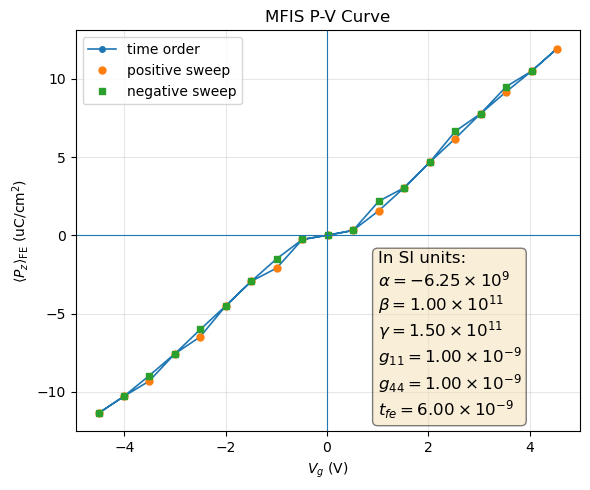

In [29]:
def sci_tex(x, sig=2):
    """Return LaTeX like 1.23\\times10^{-4} (no 'e')."""
    if x == 0:
        return r"0"
    exp = int(np.floor(np.log10(abs(x))))
    mant = x / (10 ** exp)
    return rf"{mant:.{sig}f}\times 10^{{{exp}}}"

# ==========================
# Plot PV curve
# ==========================

plt.figure(figsize=(6, 5))

textstr = '\n'.join((
    r'In SI units:',
    rf'$\alpha={sci_tex(ALPHA, sig=2)}$',
    rf'$\beta={sci_tex(BETA, sig=2)}$',
    rf'$\gamma={sci_tex(SMALL_GAMMA, sig=2)}$',
    rf'$g_{{11}}={sci_tex(G11, sig=2)}$',
    rf'$g_{{44}}={sci_tex(G44, sig=2)}$',
    rf'$t_{{fe}}={sci_tex((FE_Z_HI_NM-FE_Z_LO_NM)*1e-9, sig=2)}$',
))

props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
plt.text(1, -1, textstr, fontsize=12,
        verticalalignment='top', bbox=props)

# time-order full loop
plt.plot(V, -P*100, "-o", markersize=4, linewidth=1.2, label="time order")
# paper data
#plt.plot(Vp, Pp, "-o", markersize=4, linewidth=1.2, label="paper")
# no f data
#plt.plot(Vnf, -Pnf*100, "-o", markersize=4, linewidth=1.2, label="before")
# optional: highlight positive / negative sweep
pos = df["sweep_direction"].to_numpy() >= 0
neg = df["sweep_direction"].to_numpy() < 0

if np.any(pos):
    plt.plot(V[pos], -P[pos]*100, "o", markersize=5, label="positive sweep")

if np.any(neg):
    plt.plot(V[neg], -P[neg]*100, "s", markersize=5, label="negative sweep")


plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel(r"$V_g$ (V)")
plt.ylabel(r"$\langle P_z \rangle_\mathrm{FE}$ (uC/cm$^2$)")
plt.title("MFIS P-V Curve")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(OUT_FIG, dpi=200)
print(f"Saved figure: {OUT_FIG}")

plt.show()